# Phase contrast on moving spins

[`01_build.ipynb`](01_build.ipynb) built a bipolar pair and wrote two `.seq` files, one per
`polarity`. This notebook plays them through [MRzeroCore](https://github.com/MRsources/MRzero-Core)
on a phantom whose spins **move**, and measures the phase the encoding produces:

```text
simulate moving spins
  -> measure phase difference against velocity
  -> make the simulator's sign convention explicit
  -> show the wrap above VENC
  -> reconstruct a small velocity map
```

| | |
|---|---|
| **1** | the signal model, and why phase contrast needs two acquisitions |
| **2** | phase difference against velocity |
| **3** | the sign convention, made explicit with a static control |
| **4** | above VENC |
| **5** | a velocity map: three voxels, three velocities |
| **6** | what the simulation does and does not cover |

**Needs `MRzeroCore`, `torch` and `seqcraft`.**

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66
# Cosmetic only: MRzero re-wraps one of its own tensors.
warnings.filterwarnings('ignore', message='To copy construct from a tensor')

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'pc_gre_2d_nominal.npz')

NX, NY = (int(v) for v in nominal['matrix'])
FOV_M = float(nominal['fov_mm'][0]) / 1e3
VENC_M_S = float(nominal['venc_m_s'])
DELTA_M1 = float(nominal['delta_m1_s_per_m'])
AXIS = str(nominal['axis'])
#: `01` acquired the lines in order, so row NY // 2 is ky = 0 and column NX // 2 is the echo.
CENTRE = (NY // 2, NX // 2)


def seq_file(polarity):
    name = f'pc_gre_2d_venc{int(round(VENC_M_S * 100)):03d}_'
    return str(SEQ_DIR / (name + ('plus' if polarity > 0 else 'minus') + '.seq'))


print(f'venc     {VENC_M_S} m/s along {AXIS}')
print(f'delta_m1 {DELTA_M1} s/m   ->  pi of phase difference at {VENC_M_S} m/s')
for polarity in (+1, -1):
    imported = mr0.Sequence.import_file(seq_file(polarity))
    print(f'  polarity {polarity:+d}  {Path(seq_file(polarity)).name:<32}'
          f'{len(imported):4d} repetitions')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


venc     1.0 m/s along z
delta_m1 0.5 s/m   ->  pi of phase difference at 1.0 m/s
  polarity +1  pc_gre_2d_venc100_plus.seq        32 repetitions
  polarity -1  pc_gre_2d_venc100_minus.seq       32 repetitions


---
## 1. The model

A spin at $x(t) = x_0 + v t$ accumulates, over a gradient waveform $G$,

$$\phi \;=\; 2\pi \int G(t)\,x(t)\,\mathrm{d}t \;=\; 2\pi\,(m_0 x_0 + m_1 v)$$

The bipolar makes $m_0 = 0$, so the first term vanishes and **position drops out**: what is left
is proportional to velocity alone. But a real voxel's phase also holds coil phase, off-resonance
and susceptibility, none of which the encoding put there and none of which is known. Those are
identical in the two acquisitions, so subtracting one from the other removes them and leaves

$$\Delta\phi \;=\; 2\pi\,\Delta m_1\,v$$

which is why velocity encoding is always a **pair**: one acquisition alone cannot separate the
velocity term from the rest of the voxel's phase.

In [2]:
def simulate(polarity, *, velocities_m_s, positions_m, t2_s=0.1):
    """Play one toggle's `.seq` on a phantom whose voxels move at constant velocity along AXIS.

    Returns the k-space the sequence acquires, NY x NX.
    """
    imported = mr0.Sequence.import_file(seq_file(polarity))
    count = len(positions_m)
    built = mr0.CustomVoxelPhantom(
        pos=positions_m, PD=[1.0] * count, T1=[1.0] * count, T2=[t2_s] * count,
        T2dash=[1000.0] * count, D=[0.0] * count,
        voxel_size=FOV_M / NX, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0

    base = built.voxel_pos.clone()
    speed = torch.tensor(velocities_m_s, dtype=base.dtype)
    axis_index = 'xyz'.index(AXIS)

    def motion(t):
        """Where each voxel is at time `t`: constant velocity along the encoding axis."""
        step = torch.zeros((t.numel(), count, 3), dtype=base.dtype)
        step[:, :, axis_index] = speed[None, :] * t[:, None]
        return base[None, :, :] + step

    built.voxel_motion = motion
    graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return signal.reshape(NY, NX)


def centre_phase_difference(v_m_s):
    """The phase difference between the toggles at the centre of k-space, radians."""
    echoes = [simulate(p, velocities_m_s=[v_m_s], positions_m=[[0.0, 0.0, 0.0]])[CENTRE]
              for p in (+1, -1)]
    return float(np.angle(echoes[0] * np.conj(echoes[1])))

---
## 2. Phase difference against velocity

One voxel, moving at a known speed along the encoding axis, simulated once per toggle. The
quantity plotted is $|\Delta\phi| / \pi$ against $v / \texttt{venc}$; the sign is taken up in
section 3.

In [3]:
SPEEDS_M_S = (0.0, 0.1, 0.25, 0.5, 0.75, 0.9)

print(f'{"v / (m/s)":>10}{"v / venc":>11}{"|dphi| / pi":>14}{"error":>12}')
measured = {}
for v_m_s in SPEEDS_M_S:
    dphi = centre_phase_difference(v_m_s)
    measured[v_m_s] = dphi
    print(f'{v_m_s:10.2f}{v_m_s / VENC_M_S:11.3f}{abs(dphi) / np.pi:14.5f}'
          f'{abs(dphi) / np.pi - v_m_s / VENC_M_S:+12.2e}')

 v / (m/s)   v / venc   |dphi| / pi       error
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000226417 s
Compute Graph
Computing Graph: 0.001041042 s
Analyze Graph
Analyzing Graph: 0.000044625 s
Converting Rust -> Python: 0.00076 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000213416 s
Compute Graph
Computing Graph: 0.001060375 s
Analyze Graph
Analyzing Graph: 0.000045958 s
Converting Rust -> Python: 0.000860708 s
<<<< Rust <<<<


      0.00      0.000       0.00000   +5.83e-17
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000099959 s
Compute Graph
Computing Graph: 0.001003625 s
Analyze Graph
Analyzing Graph: 0.000057625 s
Converting Rust -> Python: 0.000653958 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000398875 s
Compute Graph
Computing Graph: 0.000980125 s
Analyze Graph
Analyzing Graph: 0.00004525 s
Converting Rust -> Python: 0.000791167 s
<<<< Rust <<<<
      0.10      0.100       0.10000   +1.27e-06
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0001955 s
Compute Graph
Computing Graph: 0.000944875 s
Analyze Graph
Analyzing Graph: 0.000043834 s
Converting Rust -> Python: 0.000680708 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000142041 s
Compute Graph
Computing Graph: 0.001063625 s
Analyze Graph
Analyzing Graph: 0.000045459 s
Converting Rust -> Python: 0.000731833 s
<<<< Rust <<<<


      0.25      0.250       0.25000   -9.80e-07
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00009425 s
Compute Graph
Computing Graph: 0.000977042 s
Analyze Graph
Analyzing Graph: 0.000048959 s
Converting Rust -> Python: 0.000768083 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000248625 s
Compute Graph
Computing Graph: 0.001031541 s
Analyze Graph
Analyzing Graph: 0.000045125 s
Converting Rust -> Python: 0.000757291 s
<<<< Rust <<<<
      0.50      0.500       0.50000   +3.17e-07
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000121916 s
Compute Graph
Computing Graph: 0.000979334 s
Analyze Graph
Analyzing Graph: 0.000045 s
Converting Rust -> Python: 0.000753 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000181875 s
Compute Graph
Computing Graph: 0.001004333 s
Analyze Graph
Analyzing Graph: 0.000044417 s
Converting Rust -> Python: 0.000634791 s
<<<< Rust <<<<
      0.75      0.750       0.74999   -1.02e-05
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0000915 s
Compute Graph
Computing Graph: 0.000999208 s
Analyze Graph
Analyzing Graph: 0.000044333 s
Converting Rust -> Python: 0.000737709 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000269166 s
Compute Graph
Computing Graph: 0.000958166 s
Analyze Graph
Analyzing Graph: 0.000044416 s
Converting Rust -> Python: 0.000726 s
<<<< Rust <<<<
      0.90      0.900       0.90000   -2.82e-06


The phase difference tracks $\pi\,v/\texttt{venc}$ across the range, which is the relation
`venc_m_s` is defined by.

---
## 3. The sign convention

The measured phase difference above is **negative** where $\phi = 2\pi(m_0 x_0 + m_1 v)$ predicts
positive. MRzero reports the opposite phase sign from that analytic convention, and a scanner may
use either — so a reconstruction has to fix the convention before it divides a phase by a moment.

A **stationary-spin $m_0$ control** makes it explicit. A spin at a known offset under a known,
deliberately non-zero zeroth moment has the same form, $\phi = 2\pi m_0 x_0$, with a moment and a
position this notebook chooses. Comparing its sign with the flow measurement's gives the
convention directly.

In [4]:
opts = pp.Opts(max_grad=40, grad_unit='mT/m', max_slew=150, slew_unit='T/m/s', B0=3.0,
               rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)
PROBE_AREA_1_PER_M = 12.0

exc = sc.modules.Excitation(opts=opts, flip_deg=20.0, thickness_mm=5.0, duration_s=1e-3)
readout = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_M * 1e3, matrix=NX,
                                   bandwidth_hz_px=500.0)
lobe = pp.make_trapezoid(channel=AXIS, area=PROBE_AREA_1_PER_M, system=opts)
after_exc = float(sc.Raster(opts.grad_raster_time).ceil(exc().duration))
probe = (sc.LogicBlock('m0_probe').add(0.0, exc())
         .add(after_exc, sc.LogicBlock().add(0.0, lobe))
         .add(after_exc + float(pp.calc_duration(lobe)) + 1e-4, readout()))
sc.compile(probe, opts, name='m0_probe').write(str(SEQ_DIR / 'm0_probe.seq'))


def probe_phase(offset_m):
    """The echo phase of a stationary voxel at a known offset, under a known zeroth moment."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / 'm0_probe.seq'))
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[1.0], T2=[0.1], T2dash=[1000.0], D=[0.0],
        voxel_size=FOV_M / NX, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    shifted = built.voxel_pos.clone()
    shifted[:, 'xyz'.index(AXIS)] += offset_m
    built.voxel_pos = shifted
    graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return complex(signal.reshape(-1)[NX // 2])


print(f'static control: a stationary voxel under m0 = {PROBE_AREA_1_PER_M} 1/m\n')
print(f'{"offset / mm":>12}{"measured / pi":>15}{"2 * m0 * x0":>14}{"ratio":>9}')
reference = probe_phase(0.0)
for offset_mm in (2.0, 5.0, -3.0):
    phase = float(np.angle(probe_phase(offset_mm / 1e3) * np.conj(reference))) / np.pi
    predicted = 2.0 * PROBE_AREA_1_PER_M * offset_mm / 1e3
    print(f'{offset_mm:12.1f}{phase:15.4f}{predicted:14.4f}{phase / predicted:9.2f}')

print(f'\n{"v / (m/s)":>12}{"measured / pi":>15}{"2 * dm1 * v":>14}{"ratio":>9}   (from section 2)')
for v_m_s in (0.25, 0.5, 0.75):
    predicted = 2.0 * DELTA_M1 * v_m_s
    print(f'{v_m_s:12.2f}{measured[v_m_s] / np.pi:15.4f}{predicted:14.4f}'
          f'{measured[v_m_s] / np.pi / predicted:9.2f}')

static control: a stationary voxel under m0 = 12.0 1/m

 offset / mm  measured / pi   2 * m0 * x0    ratio
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000006667 s
Compute Graph
Computing Graph: 0.000003458 s
Analyze Graph
Analyzing Graph: 0.000000542 s
Converting Rust -> Python: 0.000002167 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000007541 s
Compute Graph
Computing Graph: 0.000002458 s
Analyze Graph
Analyzing Graph: 0.000000375 s
Converting Rust -> Python: 0.0000015 s
<<<< Rust <<<<
         2.0        -0.0480        0.0480    -1.00
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000006666 s
Compute Graph
Computing Graph: 0.000002375 s
Analyze Graph
Analyzing Graph: 0.000000416 s
Converting Rust -> Python: 0.0000015 s
<<<< Rust <<<<
         5.0        -0.1200        0.1200    -1.00
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0000085 s
Compute Graph
Computing Graph: 0.00000275 s
Analyze Gra

**The same ratio, −1, in both.** A stationary spin under a zeroth moment and a moving spin under a
first moment relate to the analytic formula the same way, so one factor of $-1$ describes the
convention for both, and the reconstruction below applies it in one explicit line.

This is also why `polarity` is defined as the sign of the emitted **first moment**: that is a
property of the waveform, so it is fixed before any convention is chosen.

---
## 4. Above VENC, the phase wraps

$\Delta\phi$ is an angle, so it is only known modulo $2\pi$. At $v = \texttt{venc}$ it reaches
$\pi$, and one step further it is indistinguishable from $-\pi$ — which reads as fast flow in the
*opposite* direction. That is aliasing, and it is why a protocol sets `venc_m_s` above the fastest
flow it expects rather than at it.

In [5]:
WRAPPED_M_S = (0.8, 1.0, 1.2, 1.5, 1.8)

print(f'{"v / (m/s)":>10}{"v / venc":>11}{"recovered / (m/s)":>20}   ')
for v_m_s in WRAPPED_M_S:
    dphi = centre_phase_difference(v_m_s)
    recovered = -dphi / (2.0 * np.pi * DELTA_M1)      # the sign convention, applied explicitly
    if abs(v_m_s) < VENC_M_S:
        flag = ''
    elif abs(v_m_s) == VENC_M_S:
        flag = '   <- exactly pi, the edge'
    else:
        flag = '   <- wrapped'
    print(f'{v_m_s:10.2f}{v_m_s / VENC_M_S:11.3f}{recovered:20.4f}{flag}')

 v / (m/s)   v / venc   recovered / (m/s)   
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000122875 s
Compute Graph
Computing Graph: 0.0009745 s
Analyze Graph
Analyzing Graph: 0.000044458 s
Converting Rust -> Python: 0.0007685 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000236083 s
Compute Graph
Computing Graph: 0.000990083 s
Analyze Graph
Analyzing Graph: 0.000044291 s
Converting Rust -> Python: 0.000659625 s
<<<< Rust <<<<
      0.80      0.800              0.8000
>>>> Rust - compute_graph(...) >>>


Converting Python -> Rust: 0.000127209 s
Compute Graph
Computing Graph: 0.00100675 s
Analyze Graph
Analyzing Graph: 0.000045167 s
Converting Rust -> Python: 0.000721084 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000236458 s
Compute Graph
Computing Graph: 0.000998791 s
Analyze Graph
Analyzing Graph: 0.000044958 s
Converting Rust -> Python: 0.000653458 s
<<<< Rust <<<<
      1.00      1.000              1.0000   <- exactly pi, the edge
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000090958 s
Compute Graph
Computing Graph: 0.001008875 s
Analyze Graph
Analyzing Graph: 0.000044416 s
Converting Rust -> Python: 0.000713667 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000320208 s
Compute Graph
Computing Graph: 0.000985584 s
Analyze Graph
Analyzing Graph: 0.000044459 s
Converting Rust -> Python: 0.000681541 s
<<<< Rust <<<<


      1.20      1.200             -0.8000   <- wrapped
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000131791 s
Compute Graph
Computing Graph: 0.00100075 s
Analyze Graph
Analyzing Graph: 0.000048042 s
Converting Rust -> Python: 0.000772125 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000140959 s
Compute Graph
Computing Graph: 0.001003042 s
Analyze Graph
Analyzing Graph: 0.000043917 s
Converting Rust -> Python: 0.000693083 s
<<<< Rust <<<<
      1.50      1.500             -0.5000   <- wrapped
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000145833 s
Compute Graph
Computing Graph: 0.000978791 s
Analyze Graph
Analyzing Graph: 0.000044125 s
Converting Rust -> Python: 0.000654667 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000224875 s
Compute Graph
Computing Graph: 0.001000625 s
Analyze Graph
Analyzing Graph: 0.000044542 s
Converting Rust -> Python: 0.000691459 s
<<<< Rust <<<<
      1.80      1.800             -0.2000   <- wrapped


---
## 5. A velocity map

Three voxels at three positions, each moving at its own speed, imaged twice and subtracted. This
is the whole method in one cell: two images, one phase difference, one division.

In [6]:
POSITIONS_M = [[-0.05, -0.04, 0.0], [0.0, 0.03, 0.0], [0.06, 0.05, 0.0]]
TRUE_V_M_S = [0.0, 0.45, -0.70]


def reconstruct(polarity):
    space = simulate(polarity, velocities_m_s=TRUE_V_M_S, positions_m=POSITIONS_M)
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(space)))


plus, minus = reconstruct(+1), reconstruct(-1)
magnitude = np.abs(plus)
velocity_map = -np.angle(plus * np.conj(minus)) / (2.0 * np.pi * DELTA_M1)

print(f'{"voxel":>7}{"truth / (m/s)":>15}{"recovered":>12}{"error":>11}')
for (x_m, y_m, _z), truth in zip(POSITIONS_M, TRUE_V_M_S):
    column = int(round(NX / 2 + x_m / FOV_M * NX))
    row = int(round(NY / 2 + y_m / FOV_M * NY))
    found = velocity_map[row, column]
    print(f'  ({row:2d},{column:2d}){truth:15.2f}{found:12.4f}{found - truth:+11.2e}')

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000230667 s
Compute Graph
Computing Graph: 0.000987167 s
Analyze Graph
Analyzing Graph: 0.000045375 s
Converting Rust -> Python: 0.000663 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000083792 s
Compute Graph
Computing Graph: 0.000997 s
Analyze Graph
Analyzing Graph: 0.000044375 s
Converting Rust -> Python: 0.000701917 s
<<<< Rust <<<<
  voxel  truth / (m/s)   recovered      error
  (10, 9)           0.00     -0.0001  -1.20e-04
  (20,16)           0.45      0.4501  +1.25e-04
  (23,25)          -0.70     -0.7002  -1.90e-04


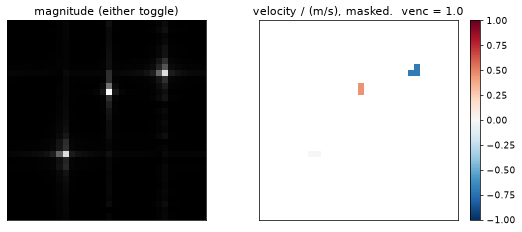

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6))
axes[0].imshow(magnitude, cmap='gray', origin='lower')
axes[0].set(title='magnitude (either toggle)')
masked = np.where(magnitude > 0.2 * magnitude.max(), velocity_map, np.nan)
image = axes[1].imshow(masked, cmap='RdBu_r', origin='lower',
                       vmin=-VENC_M_S, vmax=VENC_M_S)
axes[1].set(title=f'velocity / (m/s), masked.  venc = {VENC_M_S}')
fig.colorbar(image, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Velocity where there is signal, and nothing where there is none. The phase of noise is uniformly
distributed, so an unmasked velocity map is largely a picture of noise.

---
## 6. What this simulation covers

**Three voxels is not a flow phantom.** Each moves at a constant velocity along one axis. There
is no acceleration, no pulsatility, no partial-volume mixing of velocities within a voxel, and no
spins entering or leaving the slice — and those four are what make real phase-contrast
quantification difficult.

**Constant velocity is the case the bipolar is built for.** A spin that accelerates carries a
second-moment term as well, which this encoding does not separate from velocity.

**On resonance, at nominal $B_1$, no concomitant fields.** The simple bipolar cancels
concomitant-field phase automatically; that cancellation is not exercised here.

**Single coil, no noise.** Velocity-to-noise ratio, which is what sets a usable VENC in practice,
is outside this simulation.

---
## Summary

| | |
|---|---|
| **phase against velocity** | $\lvert\Delta\phi\rvert = \pi\,v/\texttt{venc}$ across 0 to 0.9 m/s |
| **position drops out** | $m_0 = 0$ removes the $x_0$ term, and the phase subtraction removes coil phase and off-resonance |
| **the sign is a convention** | MRzero reports $e^{-i\phi}$; a stationary-spin $m_0$ control makes it explicit |
| **above VENC it wraps** | $\pi$ and $-\pi$ are the same angle, which reads as fast flow the other way |

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §9.2 "Flow-Encoding Gradients", pp. 281–291.
- MRzeroCore, [MRsources/MRzero-Core](https://github.com/MRsources/MRzero-Core).